# Example for using climate models

This notebook aims at using the climate model class of AeroMAPS, which relies on the use of the [AeroCM](https://github.com/AeroMAPS/AeroCM) framework.

## Import librairies and configuration

In [1]:
# --- Import libraries ---
%matplotlib widget
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# --- AeroMPAS processes ---
from aeromaps import create_process

## Set models

The choice of the models is directly managed through the use of configuration files provided in `./data`.

On the one hand, some basic models from AeroMAPS are used, in addition to the default energy carriers models. Note that two specific AeroMAPS models are also studied alternatively: the `FuelEffectCorrectionContrails` model which allows taking into account the effects of alternative fuels on contrails, and the `WithoutFuelEffectCorrectionContrails` one which does not allow them.

On the other hand, the climate models are considered using the `ClimateModel` class. Currently, 4 aviation climate models are available: IPCC, GWP*, LWE, FaIR. Default settings for the different climate models are available, but the user can change them easily by modifying the yaml climate model data file. 

## Create process and computation

This example notebook uses the default AeroMAPS inputs data.

We are creating 6 processes, corresponding to 6 configuration files:
- 4 processes correspond to the different climate models with default settings, coupled to the use of the `FuelEffectCorrectionContrails` model
- 1 process correspond to the FaIR climate model with default settings, coupled to the use of the `WithoutFuelEffectCorrectionContrails` model
- 1 process is a modified version of the FaIR climate model by assuming a lower climate sensitivity to contrails, coupled to the use of the `FuelEffectCorrectionContrails` model

In [2]:
process_ipcc = create_process(configuration_file="data/config_ipcc.yaml")
process_ipcc.compute()

In [3]:
process_gwpstar = create_process(configuration_file="data/config_gwpstar.yaml")
process_gwpstar.compute()

In [4]:
process_lwe = create_process(configuration_file="data/config_lwe.yaml")
process_lwe.compute()

In [5]:
process_fair = create_process(configuration_file="data/config_fair.yaml")
process_fair.compute()
process_fair.write_json()

In [6]:
process_fair_without_fuel_effect = create_process(
    configuration_file="data/config_fair_without_fuel_effect.yaml"
)
process_fair_without_fuel_effect.compute()

In [7]:
process_fair_with_low_contrails_settings = create_process(
    configuration_file="data/config_fair_with_low_contrails_settings.yaml"
)
process_fair_with_low_contrails_settings.compute()

## Results

The user can then display the results for each configuration (e.g. default FaIR with the effects of alternative fuels on contrails).

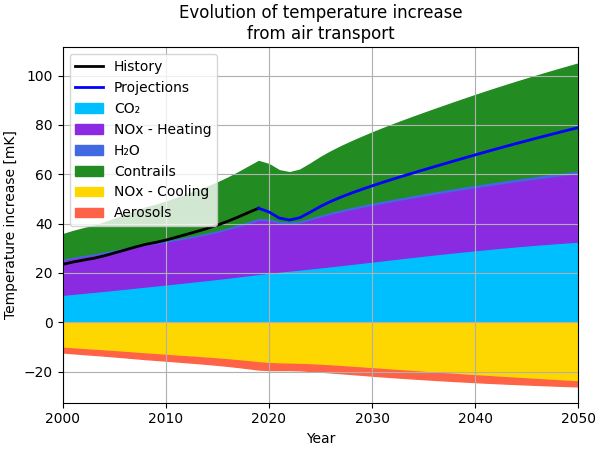

In [8]:
process_fair.plot("detailed_temperature_increase_from_air_transport")

We can for instance compare the results obtained for the different configurations.

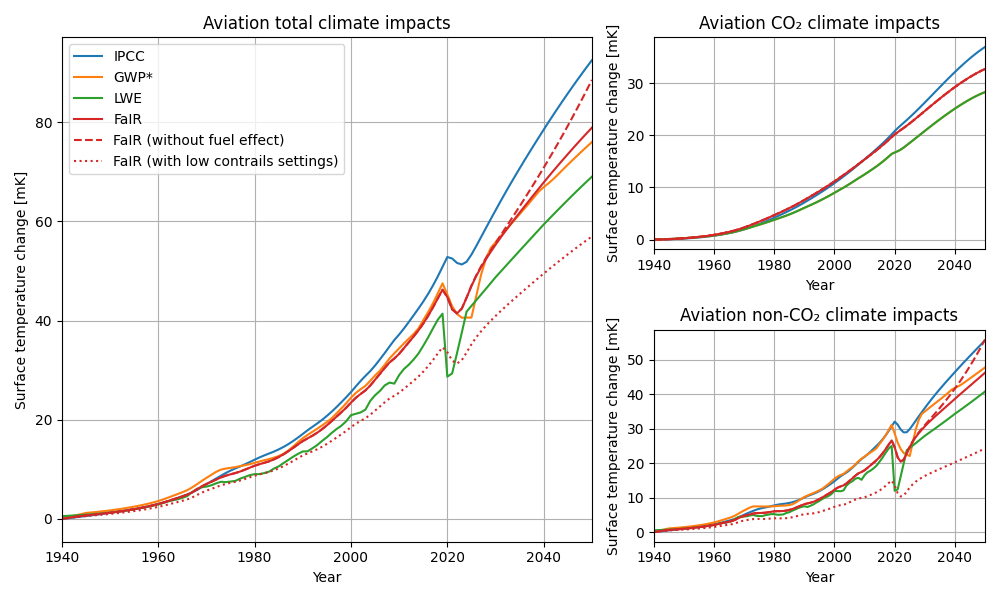

In [9]:
fig = plt.figure(figsize=(10, 6))
gs = gridspec.GridSpec(2, 2, width_ratios=[1.6, 1])
start_year = 1940
end_year = 2050
years_data = range(start_year, end_year + 1)

ax1 = fig.add_subplot(gs[:, 0])
ax1.plot(
    years_data,
    1000 * process_ipcc.data["climate_outputs"][["temperature_increase_from_aviation"]],
    label="IPCC",
)
ax1.plot(
    years_data,
    1000 * process_gwpstar.data["climate_outputs"][["temperature_increase_from_aviation"]],
    label="GWP*",
)
ax1.plot(
    years_data,
    1000 * process_lwe.data["climate_outputs"][["temperature_increase_from_aviation"]],
    label="LWE",
)
ax1.plot(
    years_data,
    1000 * process_fair.data["climate_outputs"][["temperature_increase_from_aviation"]],
    label="FaIR",
)
ax1.plot(
    years_data,
    1000
    * process_fair_without_fuel_effect.data["climate_outputs"][
        ["temperature_increase_from_aviation"]
    ],
    label="FaIR (without fuel effect)",
    color="C3",
    linestyle="--",
)
ax1.plot(
    years_data,
    1000
    * process_fair_with_low_contrails_settings.data["climate_outputs"][
        ["temperature_increase_from_aviation"]
    ],
    label="FaIR (with low contrails settings)",
    color="C3",
    linestyle=":",
)
ax1.legend()
ax1.grid()
ax1.set_xlim(start_year, end_year)
ax1.set_xlabel("Year")
ax1.set_ylabel("Surface temperature change [mK]")
ax1.set_title("Aviation total climate impacts")

ax2 = fig.add_subplot(gs[0, 1])
ax2.plot(
    years_data,
    1000 * process_ipcc.data["climate_outputs"][["temperature_increase_from_co2_from_aviation"]],
    label="IPCC",
)
ax2.plot(
    years_data,
    1000 * process_gwpstar.data["climate_outputs"][["temperature_increase_from_co2_from_aviation"]],
    label="GWP*",
)
ax2.plot(
    years_data,
    1000 * process_lwe.data["climate_outputs"][["temperature_increase_from_co2_from_aviation"]],
    label="LWE",
)
ax2.plot(
    years_data,
    1000 * process_fair.data["climate_outputs"][["temperature_increase_from_co2_from_aviation"]],
    label="FaIR",
)
ax2.plot(
    years_data,
    1000
    * process_fair_without_fuel_effect.data["climate_outputs"][
        ["temperature_increase_from_co2_from_aviation"]
    ],
    label="FaIR (without fuel effect)",
    color="C3",
    linestyle="--",
)
ax2.plot(
    years_data,
    1000
    * process_fair_with_low_contrails_settings.data["climate_outputs"][
        ["temperature_increase_from_co2_from_aviation"]
    ],
    label="FaIR (with low contrails settings)",
    color="C3",
    linestyle=":",
)
ax2.grid()
ax2.set_xlim(start_year, end_year)
ax2.set_xlabel("Year")
ax2.set_ylabel("Surface temperature change [mK]")
ax2.set_title("Aviation CO₂ climate impacts")

ax3 = fig.add_subplot(gs[1, 1])
ax3.plot(
    years_data,
    1000
    * process_ipcc.data["climate_outputs"][["temperature_increase_from_non_co2_from_aviation"]],
    label="IPCC",
)
ax3.plot(
    years_data,
    1000
    * process_gwpstar.data["climate_outputs"][["temperature_increase_from_non_co2_from_aviation"]],
    label="GWP*",
)
ax3.plot(
    years_data,
    1000 * process_lwe.data["climate_outputs"][["temperature_increase_from_non_co2_from_aviation"]],
    label="LWE",
)
ax3.plot(
    years_data,
    1000
    * process_fair.data["climate_outputs"][["temperature_increase_from_non_co2_from_aviation"]],
    label="FaIR",
)
ax3.plot(
    years_data,
    1000
    * process_fair_without_fuel_effect.data["climate_outputs"][
        ["temperature_increase_from_non_co2_from_aviation"]
    ],
    label="FaIR (without fuel effect)",
    color="C3",
    linestyle="--",
)
ax3.plot(
    years_data,
    1000
    * process_fair_with_low_contrails_settings.data["climate_outputs"][
        ["temperature_increase_from_non_co2_from_aviation"]
    ],
    label="FaIR (with low contrails settings)",
    color="C3",
    linestyle=":",
)
ax3.grid()
ax3.set_xlim(start_year, end_year)
ax3.set_xlabel("Year")
ax3.set_ylabel("Surface temperature change [mK]")
ax3.set_title("Aviation non-CO₂ climate impacts")

plt.tight_layout()
plt.show()

In [10]:
# Verify the outputs between .outputs.json and data/reference/outputs.json (only for FaIR here)
from aeromaps.utils.functions import compare_json_files

files_are_different = compare_json_files(
    "./data/reference/outputs_fair.json",
    "./data/outputs_fair.json",
    rtol=0.0001,
    atol=0,
)

if files_are_different:
    raise ValueError("The outputs.json files are different.")

Differences found:
{
  "values_changed": {
    "root['float_outputs']['temperature_target_consumed_share']": {
      "new_value": 4.271404926192157,
      "old_value": 4.270801533608842
    },
    "root['climate_outputs']['temperature_increase_from_aviation'][1]": {
      "new_value": 0.00012333214268714235,
      "old_value": 0.00012341742261512585
    },
    "root['climate_outputs']['temperature_increase_from_aviation'][2]": {
      "new_value": 0.0002928479263979659,
      "old_value": 0.0002930516781068926
    },
    "root['climate_outputs']['temperature_increase_from_aviation'][3]": {
      "new_value": 0.0004393728909901952,
      "old_value": 0.0004396807907140615
    },
    "root['climate_outputs']['temperature_increase_from_aviation'][4]": {
      "new_value": 0.0005654103142719892,
      "old_value": 0.0005658092602764224
    },
    "root['climate_outputs']['temperature_increase_from_aviation'][5]": {
      "new_value": 0.0006791354310833678,
      "old_value": 0.000679617514

ValueError: The outputs.json files are different.

In [ ]:
from aeromaps.utils.functions import clean_notebooks_on_tests

clean_notebooks_on_tests(globals())